# Explore here

# Carga del conjuto de datos 


- Problema: 

Predecir el coste del seguro médico de una persona
La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 

# Modelo 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor


In [27]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Eda 

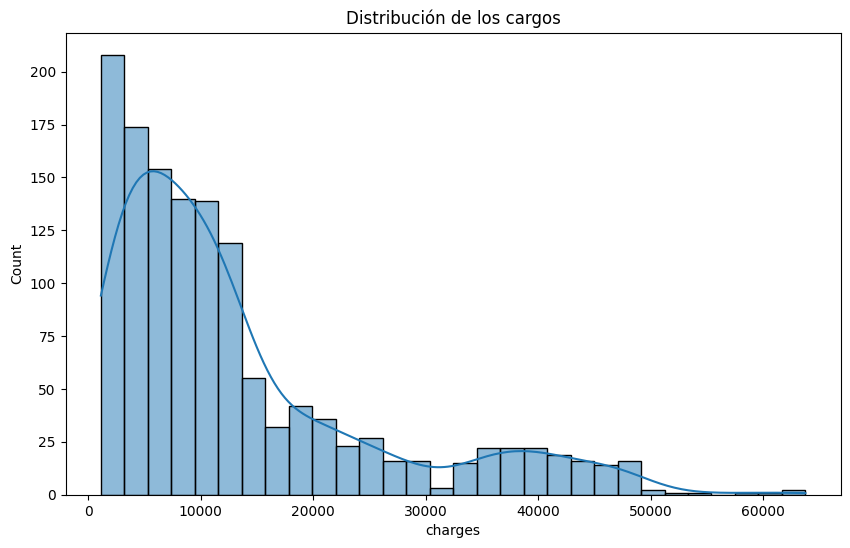

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribución de los cargos')
plt.show()

# Convertir variables Binarias 

-LeabelEncoder Manualmente.

- DE esta forma puedo controlar mejor que número es cada uno, aunque tambien esta la otra forma. 

In [30]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})


In [31]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


- One-hot Encoding


In [32]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)


In [33]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


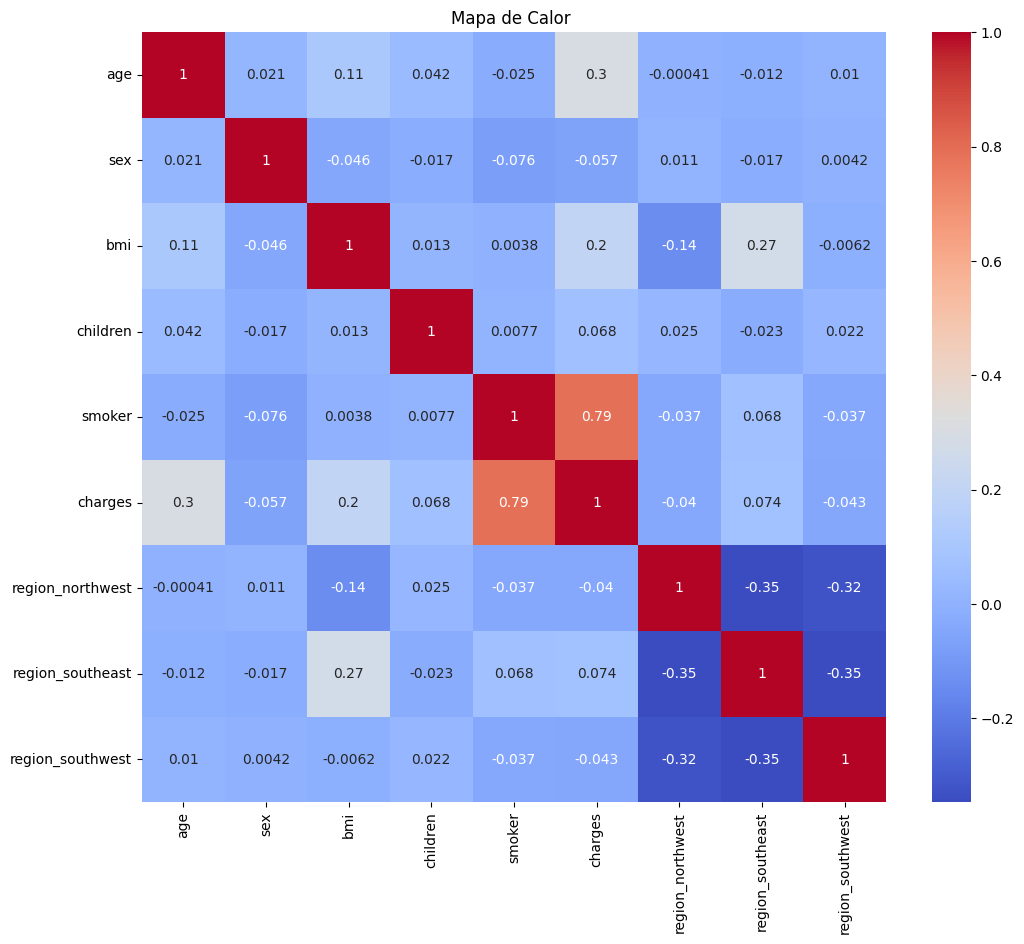

In [34]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor ')
plt.show()

# Entreno

In [36]:


X = df.drop('charges', axis=1) 
y = df['charges']              


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo 

In [44]:

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")


RMSE: 5796.28


# Mejora del Modelo con RamdonForest 

In [45]:

bosque = RandomForestRegressor(n_estimators=100, random_state=42)

bosque.fit(X_train, y_train)

y_pred_bosque = bosque.predict(X_test)


mse_bosque = mean_squared_error(y_test, y_pred_bosque)
rmse_bosque = np.sqrt(mse_bosque)

print(f"🌲: {rmse_bosque:.2f}")

🌲: 4550.74


- Con el ramdonforest hemos bajado  más de 1200 puntos respecto a la regresión lineal. 

# Conclusión: 
 
 - Con la utilización del Random Forest funciona mejor aquí porque entiende que las variables (como fumar y la edad) no siguen una línea recta simple. lo cual quiere decir que antes con de modelo de regresion lineal  se  le decia a "pepe, oye tu prima  suele variar unos 5.796$ arriba o abajo" , pero luego con la utilizacion del Ramdomforest elmargen de error a bajado y se puede sacar una prima de seguro con mejor excatitud. 